In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import chirp

# Make project root importable when running from Modeling/tasks/Basic_FE_sweeps
project_root = Path.cwd().parents[2]
sys.path.insert(0, str(project_root))

from Modeling.models.FE3 import PiezoBeamFE
from Modeling.models.beam_properties import PiezoBeamParams
from Modeling.models import FE_helpers

# 1) FE model
params = PiezoBeamParams(hp=0.252e-3, hs=0.51e-3)
fe = PiezoBeamFE(params)

# 2) Chirp first, then hold the last frequency as a harmonic excitation
amp = 50
f0 = 500
f = 5000
t1 = 20
t_end = t1
dt = 1 / f/ 50
K_p = 0.015

# Start from 0 Hz and sweep up to f over [0, t1], then continue at f
def v_exc(t):
    if t < t1:
        return amp * chirp(t, f0=0, f1=f, t1=t1, method="linear")
    return amp * np.cos(2 * np.pi * f * t)

def v_exc(t):
    return amp * chirp(t, f0=0, f1=f, t1=t1, method="linear")
# plt.figure(figsize=(8, 3))
# t_plot = np.arange(0, t_end, dt)
# plt.plot(t_plot, [v_exc(t) for t in t_plot])
# plt.xlabel('time [s]')
# plt.xlim(0.495, 0.505)
# plt.show()


In [11]:
import pickle

ode_kwargs = dict(
    j_exc=30,
    K_p=0.015,
    K_i=1820,
    K_c=3e10,
    R_c=1e3,
    v_exc=v_exc,
)

ode = fe.build_ode_system(**ode_kwargs)
out_freq = FE_helpers.frf_sweep(ode, omega_vec=np.linspace(f0, f, 1000)*2*np.pi)



FRF sweep: 100%|██████████| 1000/1000 [00:05<00:00, 199.66it/s]


In [ ]:

# 3) Time-domain solve (kept intentionally short for a quick baseline run)
out = FE_helpers.solve_newmark(
    ode=ode,
    dt=dt,  # 80 points per cycle
    t_end=t_end,
    beta=0.25,
    gamma=0.5,
    do_spectral=True,
)

save_dir = Path.cwd() / "sim_dat" / "single_run"
save_dir.mkdir(parents=True, exist_ok=True)
save_path = save_dir / "results.pkl"
run_data = {
    **out,
    "params": {
        "amp": amp,
        "f0": f0,
        "f": f,
        "t1": t1,
        "t_end": t_end,
        "dt": dt,
        "ode": {k: v for k, v in ode_kwargs.items() if k != "v_exc"},
        "beam": vars(params),
    },
}

with open(save_path, "wb") as fobj:
    pickle.dump(run_data, fobj)

print(f"Saved: {save_path}")

In [1]:
# Load previously saved Newmark results (skip solve step if file exists)
import pickle
from pathlib import Path

load_path = Path.cwd() / "sim_dat" / "single_run" / "results.pkl"
if not load_path.exists():
    raise FileNotFoundError(f"Saved file not found: {load_path}")

with open(load_path, "rb") as fobj:
    loaded = pickle.load(fobj)

# `loaded` may already be the `out` dict with an extra `params` key.
out = {k: v for k, v in loaded.items() if k != "params"}
saved_params = loaded.get("params", {})

print(f"Loaded: {load_path}")
print("Keys in out:", sorted(out.keys()))
print("u_ddot shape:", out["u_ddot"].shape)
print("Saved params keys:", sorted(saved_params.keys()))

Loaded: c:\Users\setemadi3\GaTech Dropbox\Seyednima Etemadi\Projects\Metamaterial beam\Modeling\tasks\Chaotic_band\sim_dat\single_run\results.pkl
Keys in out: ['q', 'spectral', 't', 'u', 'u_ddot', 'u_dot', 'v', 'x', 'x_ddot', 'x_dot']
u_ddot shape: (5000001, 157)
Saved params keys: ['amp', 'beam', 'dt', 'f', 'f0', 'ode', 't1', 't_end']


In [12]:
out_freq['u'].shape

(1000, 157)

In [4]:
mech_idx = 50
elec_idx = 25

FRF = np.fft.rfft(out['u_dot'], axis=0)
freqs = np.fft.rfftfreq(len(out['t']), dt) 


In [11]:
np.mean(np.abs(FRF), axis=1).shape

(2500001,)

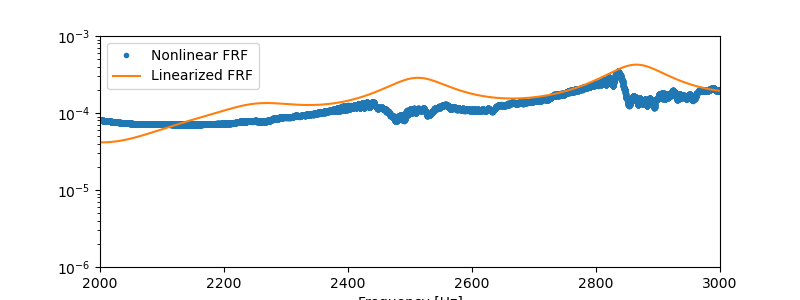

In [12]:
 
plt.figure(figsize=(8, 3)) 
plt.semilogy(freqs, np.mean(np.abs(FRF), axis=1)/np.abs(np.fft.rfft(v_exc(out['t']))), '.' ,  label= 'Nonlinear FRF ') 
plt.semilogy(out_freq['freq'] , np.mean(np.abs(out_freq['u_dot']) , axis=1) , label='Linearized FRF') 
plt.xlabel('Frequency [Hz]') 
plt.xlim(2000, 3000)
plt.ylim(1e-6,1e-3) 
plt.legend()
plt.show()

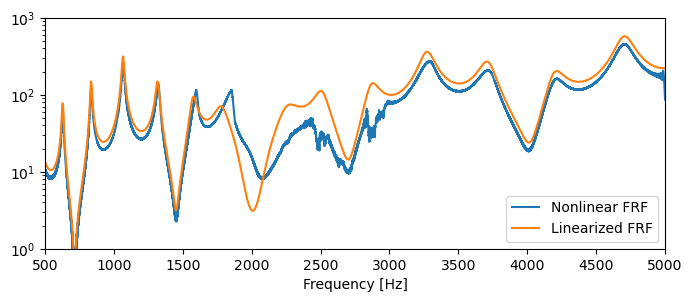

In [ ]:
mech_idx = 50
elec_idx = 25

FRF = np.fft.rfft(out['u_dot'], axis=0)/ np.fft.rfft(v_exc(out['t'])) 
freqs = np.fft.rfftfreq(len(out['t']), dt) 
plt.figure(figsize=(8, 3)) 
plt.semilogy(freqs, np.abs(FRF[:, mech_idx]), label= 'Nonlinear FRF ') 
plt.semilogy(out_freq['freq'] , np.abs(out_freq['u_dot'][:, mech_idx]) * 5e5, label='Linearized FRF') 
plt.xlabel('Frequency [Hz]') 
plt.xlim(500, f)
plt.ylim(1e0, 1e3) 
plt.legend()
plt.show()

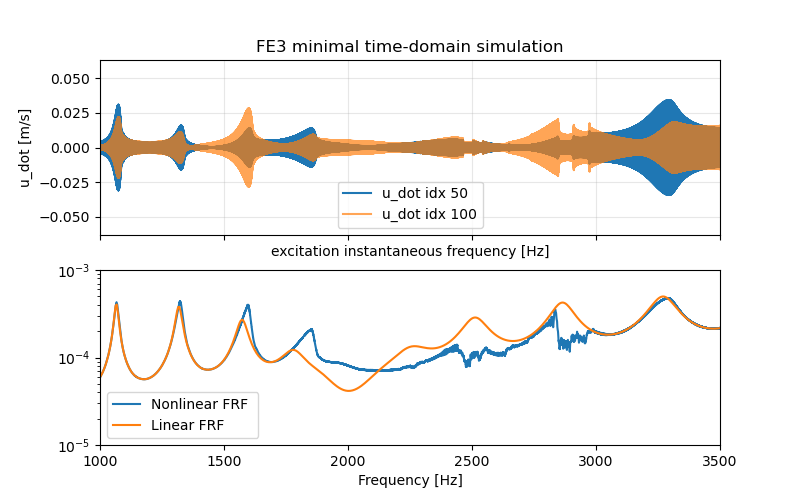

u_dot shape: (5000001, 157)
v shape: (5000001, 30)


In [22]:
%matplotlib widget
# 4) Plot one mechanical and one electrical response channel
t = out['t']
mech_idx = [50 , 100]
f1, f2 = 1000, 3500
fig, ax = plt.subplots(2, 1, figsize=(8, 5),  sharex= True)
f_inst = f * np.clip(t, 0, t1) / t1
ax[0].plot(f_inst, out['u_dot'][:, mech_idx[0]], label= f'u_dot idx {mech_idx[0]}')   
ax[0].plot(f_inst, out['u_dot'][:, mech_idx[1]], label= f'u_dot idx {mech_idx[1]}', alpha=0.7)   

ax[0].set_ylabel('u_dot [m/s]')
ax[0].set_xlabel('excitation instantaneous frequency [Hz]')
ax[0].set_title('FE3 minimal time-domain simulation')
ax[0].grid(True, alpha=0.3)
ax[0].legend()
ax[0].set_xlim(f1, f2)

ax[1].semilogy(freqs, np.mean(np.abs(FRF), axis=1)/np.abs(np.fft.rfft(v_exc(out['t']))) ,  label= 'Nonlinear FRF ') 
ax[1].semilogy(out_freq['freq'] , np.mean(np.abs(out_freq['u_dot']) , axis=1) , label='Linear FRF') 
ax[1].set_xlabel('Frequency [Hz]') 
ax[1].set_xlim(f1, f2)
ax[1].set_ylim(1e-5,1e-3) 
ax[1].legend()
# ax[1].set_xlim(0.5, 0.51)
# plt.tight_layout()
plt.show()

print('u_dot shape:', out['u_dot'].shape)
print('v shape:', out['v'].shape)

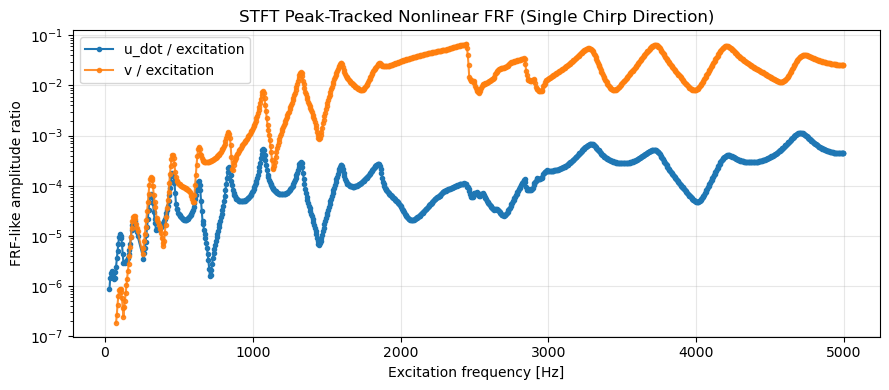

In [ ]:
# 5) Nonlinear FRF-style analysis via STFT peak tracking (aligned with Analyze_nonlinear_FRF_chirp)
from scipy.signal import stft
import scipy.io

analysis_dir = Path.cwd() / "sim_dat" / "single_run" / "spectrogram_analysis"
analysis_dir.mkdir(parents=True, exist_ok=True)

# Signals
time = out["t"]
fs = 1.0 / dt
exc_signal = np.array([v_exc(tt) for tt in time])
mech_signal = out["u_dot"][:, mech_idx]
volt_signal = out["v"][:, elec_idx]

# STFT settings (same style as Analyze_nonlinear_FRF_chirp)
win_len_sec = 0.1
win_len = int(fs * win_len_sec)
# win_len = max(128, min(win_len, len(time) // 4))
hop_len = int(0.2 * win_len)
# hop_len = max(1, hop_len)
mfft = 2 ** (int(np.log2(win_len)) + 5)
window = np.ones(win_len)

def frf_unidirectional_stft(output_signal, input_signal):
    f_stft, t_spec, z_out = stft(
        output_signal, fs=fs, window=window, nperseg=win_len, noverlap=win_len - hop_len, nfft=mfft
    )
    _, _, z_in = stft(
        input_signal, fs=fs, window=window, nperseg=win_len, noverlap=win_len - hop_len, nfft=mfft
    )

    out_freqs, in_freqs = [], []
    out_amps, in_amps = [], []

    for i in range(z_out.shape[1]):
        out_peak_idx = np.argmax(np.abs(z_out[:, i]))
        in_peak_idx = np.argmax(np.abs(z_in[:, i]))
        out_freqs.append(np.abs(f_stft[out_peak_idx]))
        in_freqs.append(np.abs(f_stft[in_peak_idx]))
        out_amps.append(np.abs(z_out[out_peak_idx, i]))
        in_amps.append(np.abs(z_in[in_peak_idx, i]))

    return (
        np.array(in_amps),
        np.array(out_amps),
        np.array(in_freqs),
        np.array(out_freqs),
        t_spec,
    )

def remove_outliers(yin, yout, fin, fout, freq_tol_hz=40.0, min_in_amp=1e-14):
    # Keep frames where input and output dominant frequencies are close enough.
    freq_ok = np.abs(fin - fout) <= freq_tol_hz
    amp_ok = np.abs(yin) > min_in_amp
    inds = freq_ok & amp_ok
    return yin[inds], yout[inds], fin[inds], fout[inds], inds

# Mechanical FRF-like curve: u_dot / excitation
base_mech_amps, out_mech_amps, base_mech_freqs, out_mech_freqs, t_spec = frf_unidirectional_stft(
    mech_signal, exc_signal
)
base_mech_amps, out_mech_amps, base_mech_freqs, out_mech_freqs, inds_mech = remove_outliers(
    base_mech_amps, out_mech_amps, base_mech_freqs, out_mech_freqs
)
mech_frf = out_mech_amps / base_mech_amps

# Electrical FRF-like curve: v / excitation
base_volt_amps, out_volt_amps, base_volt_freqs, out_volt_freqs, _ = frf_unidirectional_stft(
    volt_signal, exc_signal
)
base_volt_amps, out_volt_amps, base_volt_freqs, out_volt_freqs, inds_volt = remove_outliers(
    base_volt_amps, out_volt_amps, base_volt_freqs, out_volt_freqs
)
volt_frf = out_volt_amps / base_volt_amps

# Since this run uses one chirp direction, this is the up-sweep equivalent.
plt.figure(figsize=(9, 4))
plt.semilogy(base_mech_freqs, mech_frf, ".-", label="u_dot / excitation")
plt.semilogy(base_volt_freqs, volt_frf, ".-", label="v / excitation", alpha=0.85)
plt.xlabel("Excitation frequency [Hz]")
plt.ylabel("FRF-like amplitude ratio")
plt.title("STFT Peak-Tracked Nonlinear FRF (Single Chirp Direction)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
frf_fig_path = analysis_dir / "frf_peak_tracked.png"
plt.savefig(frf_fig_path, dpi=180)
plt.show()

# Also show a spectrogram for mechanical signal with tracked peak frequency.
f_stft, t_stft, z_mech = stft(
    mech_signal, fs=fs, window="hann", nperseg=win_len, noverlap=win_len - hop_len, nfft=mfft
)
s_db = 20 * np.log10(np.abs(z_mech) + 1e-20)

peak_track = np.full(t_stft.shape, np.nan)
for i in range(z_mech.shape[1]):
    peak_track[i] = np.abs(f_stft[np.argmax(np.abs(z_mech[:, i]))])

plt.figure(figsize=(10, 4.5))
plt.pcolormesh(t_stft, f_stft, s_db, shading="auto", cmap="magma")
plt.plot(t_stft, peak_track, "c-", lw=1.5, label="dominant peak track")
plt.ylim(0, min(fs / 2, 1.5 * f))
plt.xlabel("Time [s]")
plt.ylabel("Frequency [Hz]")
plt.title("Mechanical Spectrogram with Peak Tracking")
plt.colorbar(label="STFT magnitude [dB]")
plt.legend()
plt.tight_layout()
spec_fig_path = analysis_dir / "mech_spectrogram_peak_track.png"
plt.savefig(spec_fig_path, dpi=180)
plt.show()

# Save analysis artifacts (npz + mat).
np.savez(
    analysis_dir / "frf_peak_tracked_results.npz",
    base_mech_freqs=base_mech_freqs,
    out_mech_freqs=out_mech_freqs,
    mech_frf=mech_frf,
    base_volt_freqs=base_volt_freqs,
    out_volt_freqs=out_volt_freqs,
    volt_frf=volt_frf,
    t_stft=t_stft,
    peak_track=peak_track,
    win_len=win_len,
    hop_len=hop_len,
    mfft=mfft,
    fs=fs,
)

scipy.io.savemat(
    analysis_dir / "frf_peak_tracked_results.mat",
    {
        "base_mech_freqs": base_mech_freqs,
        "out_mech_freqs": out_mech_freqs,
        "mech_frf": mech_frf,
        "base_volt_freqs": base_volt_freqs,
        "out_volt_freqs": out_volt_freqs,
        "volt_frf": volt_frf,
        "t_stft": t_stft,
        "peak_track": peak_track,
    },
)

print(f"Saved FRF figure: {frf_fig_path}")
print(f"Saved spectrogram figure: {spec_fig_path}")
print(f"Saved NPZ: {analysis_dir / 'frf_peak_tracked_results.npz'}")
print(f"Saved MAT: {analysis_dir / 'frf_peak_tracked_results.mat'}")